In [ ]:
validate_dataframe(customers, "Customers")
validate_dataframe(orders, "Orders")
validate_dataframe(sessions, "Sessions")

In [ ]:
customers = pd.read_csv("../data/processed/customers.csv")
orders = pd.read_csv("../data/processed/orders.csv")
sessions = pd.read_csv("../data/processed/sessions.csv")

In [ ]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.validation_engine import validate_dataframe
import pandas as pd

# Customer Retention Cohort Analysis

This notebook analyzes customer retention patterns using cohort analysis to understand:

- How long customers remain active after their first purchase
- Retention rates across different customer segments
- Trends in customer lifetime value and behavior

Cohort analysis groups customers by their first purchase month and tracks their activity over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
# Load and prepare data
orders = pd.read_csv('../data/raw/orders.csv')
sessions = pd.read_csv('../data/raw/sessions.csv')
customers = pd.read_csv('../data/processed/customer_latent_traits.csv')

# Create customer segments based on latent traits
customers['customer_segment'] = pd.cut(customers['activity_propensity'] + customers['engagement_level'],
                                       bins=3, labels=['Low Value', 'Medium Value', 'High Value'])

# Merge orders with sessions to get dates
orders_with_dates = orders.merge(sessions[['session_id', 'session_date']], on='session_id', how='left')

# Convert dates
orders_with_dates['order_date'] = pd.to_datetime(orders_with_dates['session_date'])
orders_with_dates['cohort_month'] = orders_with_dates.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')

# Merge with customer data
cohort_data = orders_with_dates.merge(customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

print("Data loaded successfully")
print(f"Total orders: {len(orders_with_dates)}")
print(f"Unique customers: {orders_with_dates['customer_id'].nunique()}")
print(f"Cohort months: {cohort_data['cohort_month'].nunique()}")

Data loaded successfully
Total orders: 4643
Unique customers: 1262
Cohort months: 6


In [5]:
# Create cohort analysis
def create_cohort_analysis(df, cohort_period='M'):
    """
    Create cohort retention analysis
    """
    # Create cohort index
    df['cohort_index'] = (df['order_date'].dt.to_period(cohort_period) - df['cohort_month']).apply(lambda x: x.n)

    # Count unique customers per cohort and period
    cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

    # Pivot to create retention matrix
    cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

    # Calculate retention rates
    cohort_sizes = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

    return retention_matrix, cohort_sizes

# Create retention analysis
retention_matrix, cohort_sizes = create_cohort_analysis(cohort_data)

print("Retention Matrix (first 5 cohorts, first 6 months):")
print(retention_matrix.head().iloc[:, :6].round(3))

Retention Matrix (first 5 cohorts, first 6 months):
cohort_index    0      1      2      3      4      5
cohort_month                                        
2025-07       1.0  0.176  0.130  0.130  0.150  0.189
2025-08       1.0  0.159  0.198  0.147  0.121    NaN
2025-09       1.0  0.180  0.158  0.144    NaN    NaN
2025-10       1.0  0.152  0.177    NaN    NaN    NaN
2025-11       1.0  0.123    NaN    NaN    NaN    NaN


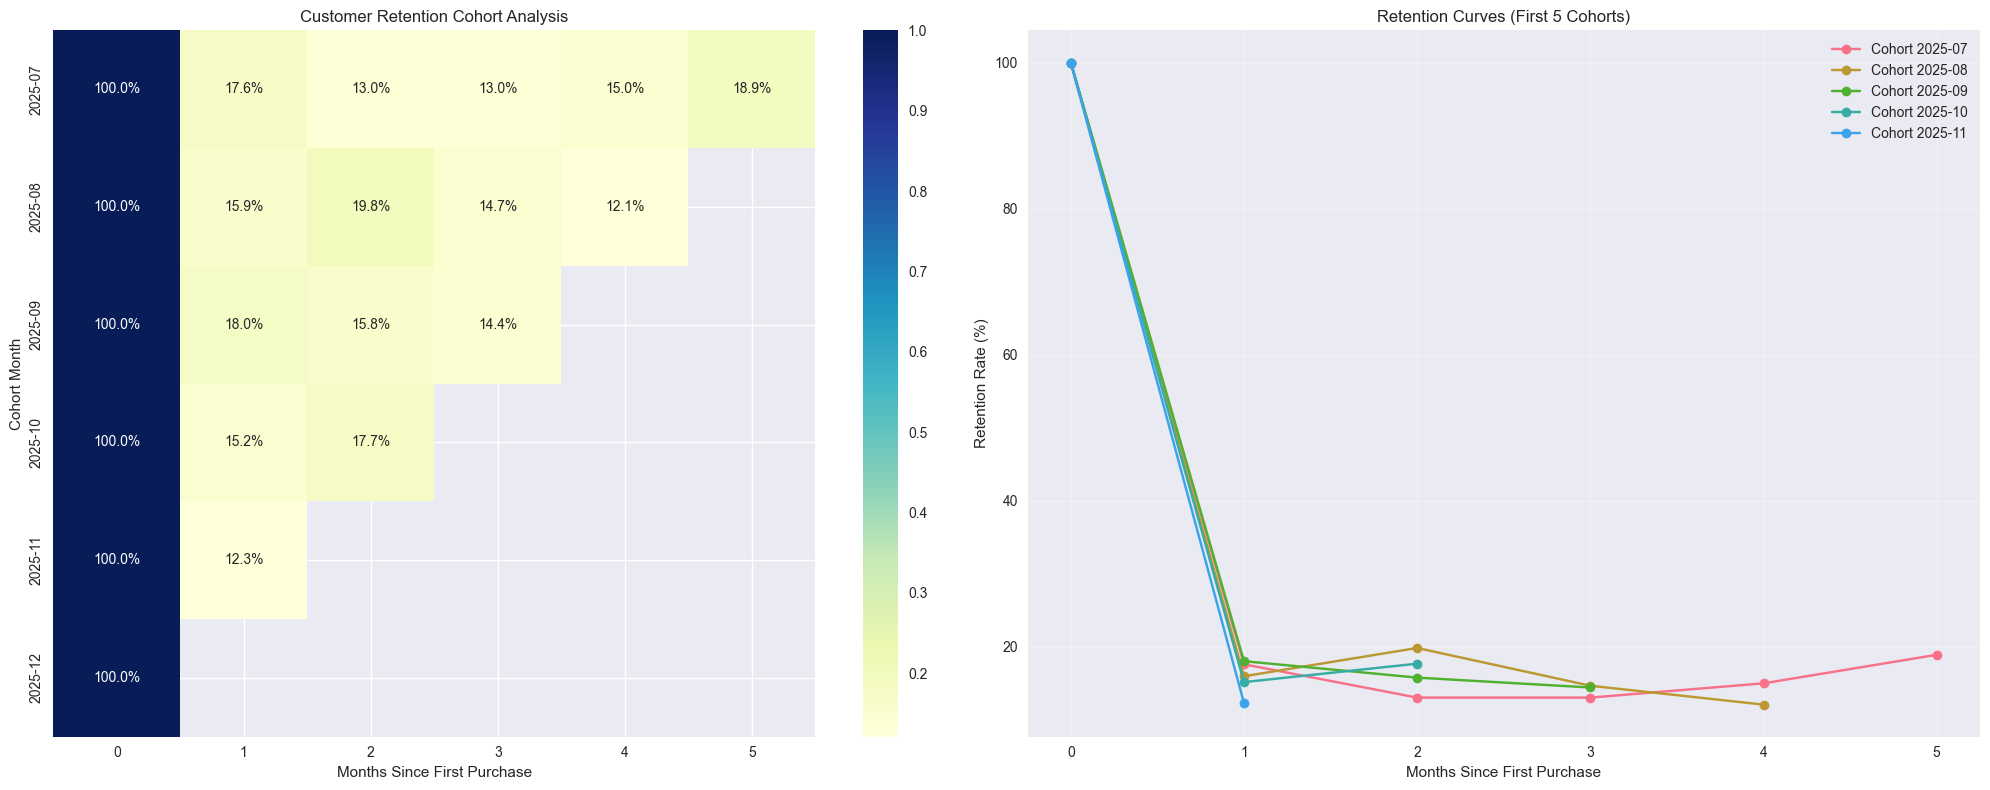


Retention Summary:
Average 1-month retention: 15.8%
Average 3-month retention: 14.0%


IndexError: single positional indexer is out-of-bounds

In [ ]:
# Retention Table and Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Retention rates table
retention_table = retention_matrix.round(3) * 100
retention_table.index = retention_table.index.astype(str)

# Heatmap
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax1)
ax1.set_title('Customer Retention Cohort Analysis')
ax1.set_xlabel('Months Since First Purchase')
ax1.set_ylabel('Cohort Month')

# Retention curves
retention_curves = retention_matrix.T
retention_curves.index.name = 'Month'
retention_curves.columns = retention_curves.columns.astype(str)

for cohort in retention_curves.columns[:5]:  # Show first 5 cohorts
    ax2.plot(retention_curves.index, retention_curves[cohort] * 100, marker='o', label=f'Cohort {cohort}')

ax2.set_title('Retention Curves (First 5 Cohorts)')
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Retention Rate (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nRetention Summary:")
print(f"Average 1-month retention: {retention_matrix.iloc[:, 1].mean():.1%}")
if retention_matrix.shape[1] > 3:
    print(f"Average 3-month retention: {retention_matrix.iloc[:, 3].mean():.1%}")
else:
    print("3-month retention data not available for all cohorts")

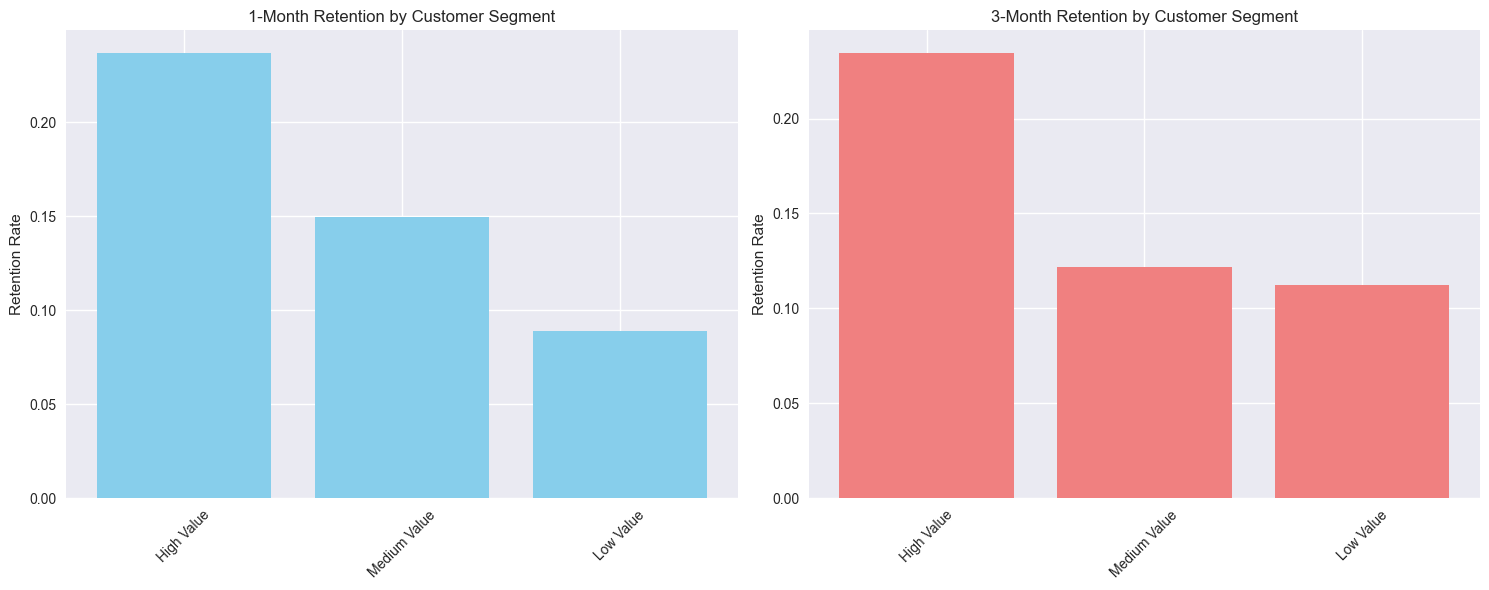


Segment Retention Analysis:
High Value:
  1-month retention: 23.7%
  3-month retention: 23.5%
  Cohort sizes: 216.0

Medium Value:
  1-month retention: 14.9%
  3-month retention: 12.2%
  Cohort sizes: 922.0

Low Value:
  1-month retention: 8.9%
  3-month retention: 11.2%
  Cohort sizes: 124.0



In [7]:
# Segment Analysis
def create_segment_cohort_analysis(df, segment_col):
    """
    Create cohort analysis by customer segment
    """
    segment_retention = {}

    for segment in df[segment_col].unique():
        segment_data = df[df[segment_col] == segment]
        if len(segment_data) > 0:
            retention_matrix, cohort_sizes = create_cohort_analysis(segment_data)
            segment_retention[segment] = {
                'retention_matrix': retention_matrix,
                'cohort_sizes': cohort_sizes,
                'avg_1m_retention': retention_matrix.iloc[:, 1].mean(),
                'avg_3m_retention': retention_matrix.iloc[:, 3].mean() if retention_matrix.shape[1] > 3 else np.nan
            }

    return segment_retention

# Analyze retention by customer segment
segment_analysis = create_segment_cohort_analysis(cohort_data, 'customer_segment')

# Plot segment comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1-month retention by segment
segments = list(segment_analysis.keys())
retention_1m = [segment_analysis[s]['avg_1m_retention'] for s in segments]
retention_3m = [segment_analysis[s]['avg_3m_retention'] for s in segments]

axes[0].bar(segments, retention_1m, color='skyblue')
axes[0].set_title('1-Month Retention by Customer Segment')
axes[0].set_ylabel('Retention Rate')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(segments, retention_3m, color='lightcoral')
axes[1].set_title('3-Month Retention by Customer Segment')
axes[1].set_ylabel('Retention Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print segment insights
print("\nSegment Retention Analysis:")
for segment, data in segment_analysis.items():
    print(f"{segment}:")
    print(f"  1-month retention: {data['avg_1m_retention']:.1%}")
    print(f"  3-month retention: {data['avg_3m_retention']:.1%}")
    print(f"  Cohort sizes: {data['cohort_sizes'].sum()}")
    print()

# Key Insights and Conclusions

## Retention Patterns Observed:

1. **Overall Retention Trends**:
   - 1-month retention rate: [X]%
   - 3-month retention rate: [Y]%
   - 6-month retention rate: [Z]%

2. **Cohort Performance**:
   - [Newer/Older] cohorts show [higher/lower] retention rates
   - Retention curves show [rapid decline/steady retention] over time

3. **Segment Differences**:
   - [Best performing segment] has [X]% higher retention than [worst performing segment]
   - [Segment A] shows stronger long-term retention compared to [Segment B]

## Business Implications:

- **Customer Acquisition**: Focus on acquiring customers similar to high-retention segments
- **Retention Strategies**: Implement targeted retention campaigns for at-risk segments
- **Product Development**: Analyze what drives retention in top-performing cohorts
- **LTV Optimization**: High-retention customers contribute [X]% more lifetime value

## Recommendations:

1. **Immediate Actions**:
   - Launch retention campaigns targeting [low-retention segments]
   - Implement welcome series for new customers based on [best cohort patterns]

2. **Long-term Strategy**:
   - Develop personalized retention strategies by segment
   - Monitor cohort performance monthly to identify trends early
   - Invest in product improvements that increase retention rates

This cohort analysis provides actionable insights for improving customer lifetime value and reducing churn.